# ReservoirPy ESN Hyperparameter Search Tutorial

This notebook is a tutorial version of `test-predict-random-optim-HP.py`.

It shows how to:

- load or create multivariate time series shaped as `(timesteps, features)`;
- create one-step-ahead or lagged prediction pairs;
- run a parallel ReservoirPy hyperparameter search;
- change the search space yourself;
- optionally add new hyperparameters such as `warmup` or `lag`;
- fit a final `RidgeCV` readout with `ScikitLearnNode` after the reservoir hyperparameters have been selected.

The default cells use random data so the notebook is runnable as-is. Replace the data-loading cell with your own dataset when you are ready.

## 1. Imports

ReservoirPy 0.4.x uses `parallel_research` for fastocd CPU-parallel hyperparameter search. The final model uses `ScikitLearnNode(model=RidgeCV, ...)` which enables to load Scikit-learn models like RidgeCV.

In [16]:
import json
import re
import tempfile
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np

import reservoirpy as rpy
from reservoirpy.hyper import parallel_research, plot_hyperopt_report
from reservoirpy.nodes import Reservoir, Ridge, ScikitLearnNode

from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.base")

np.random.seed(42)
rpy.set_seed(42)

## 2. User-editable settings

The tutorial defaults are intentionally small enough to test quickly. For a serious run, increase `hp_max_evals`, `instances_per_trial`, and `N`.

The search space syntax follows ReservoirPy hyperopt conventions:

- `["choice", value1, value2, ...]` selects among fixed values;
- `["loguniform", low, high]` samples on a logarithmic scale;
- `["uniform", low, high]` samples on a linear scale;
- `["randint", low, high]` samples integer values.

You can add parameters later, but the objective function signature must include them.

In [17]:
HYPER_SEARCH_CONFIG = {
    "exp": "brainhack",
    "hp_max_evals": 100,          # Use 200, or more for broader HP searches.
    "hp_method": "random",     # ReservoirPy parallel_research supports random search.
    "seed": 42,
    "instances_per_trial": 3,   # Use 5+ for more robust estimates.
    "hp_space": {
        "N": ["choice", 50],
        "sr": ["loguniform", 1e-3, 1e3],
        "lr": ["loguniform", 1e-4, 1],
        "input_scaling": ["loguniform", 1e-3, 3],
        "ridge": ["loguniform", 1e-9, 1e3],
        "seed": ["choice", 1234],
    },
}

WARMUP = 20
LAG = 1
RESERVOIR_WORKERS = 1

HYPEROPT_SEARCH_DIR = Path("hyperopt-search")
HYPEROPT_PLOT_FIGSIZE = (16, 12)
HYPEROPT_PLOT_DPI = 100
HYPEROPT_REPORT_PREFIX = "hyper-search-report"

RESULT_CALL_RE = re.compile(r"^(?P<prefix>.+?)_(?:\d+call|call\d+)(?P<suffix>\.json)$")

## 3. Load your data here

This is the main cell to replace with your own data.

Expected format:

```python
series_list = [subject_1, subject_2, ...]
```

where each subject/session is a NumPy array shaped as:

```text
(timesteps, features)
```

For fMRI/BOLD data, `features` could be voxels, parcels, ROIs, PCA components, or any other multivariate signal representation.

The subjects do not need to have the same number of timesteps, but they must have the same number of features if you use one common scaler and one shared readout.

In [18]:
# DEMO DATA. Replace this block with your own loader.
n_subjects = 10
n_timesteps = 4000
n_features = 200

series_list = [
    np.random.randn(n_timesteps, n_features).astype(np.float32)
    for _ in range(n_subjects)
]

print(f"Loaded {len(series_list)} time series.")
print("First series shape:", series_list[0].shape)

Loaded 10 time series.
First series shape: (4000, 200)


### Example: loading your own files

If your data are saved as `.npy` files, a typical replacement is:

```python
data_dir = Path("/path/to/my/data")
series_list = [np.load(path) for path in sorted(data_dir.glob("*.npy"))]
```

If your data are in CSV files with rows as timesteps and columns as features:

```python
series_list = [np.loadtxt(path, delimiter=",") for path in sorted(data_dir.glob("*.csv"))]
```

Always check that each array has shape `(timesteps, features)`.

## 4. Train/test split and lagged prediction pairs

The original script predicts the next timestep:

```text
x[t] -> x[t+1]
```

This notebook uses a `LAG` variable:

```text
x[t] -> x[t+LAG]
```

This can be useful in fMRI when the input signal and the target are delayed relative to each other, for example because of the hemodynamic/BOLD response.

In [19]:
def make_lagged_pairs(series, lag):
    if lag < 1:
        raise ValueError("lag must be >= 1")
    if series.shape[0] <= lag:
        raise ValueError("series must contain more timesteps than lag")
    return series[:-lag], series[lag:]


train_series = series_list[:8]
test_series = series_list[8:]

X_train, Y_train = zip(*(make_lagged_pairs(s, LAG) for s in train_series))
X_test, Y_test = zip(*(make_lagged_pairs(s, LAG) for s in test_series))

X_train = list(X_train)
Y_train = list(Y_train)
X_test = list(X_test)
Y_test = list(Y_test)

print("X_train[0] shape:", X_train[0].shape)
print("Y_train[0] shape:", Y_train[0].shape)

X_train[0] shape: (3999, 200)
Y_train[0] shape: (3999, 200)


### If you already have separate inputs and targets

If your experiment already provides separate input and output signals, you can skip `make_lagged_pairs` and define:

```python
X_train = [...]
Y_train = [...]
X_test = [...]
Y_test = [...]
```

Each `X_*[i]` and `Y_*[i]` must have the same number of timesteps after any lag/warmup handling.

## 5. Scaling

We fit the scaler only on the training subjects, then apply it to train and test data. This avoids leaking test information into the training process.

In [20]:
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(np.vstack(train_series))

X_train_scaled = [scaler.transform(x) for x in X_train]
Y_train_scaled = [scaler.transform(y) for y in Y_train]
X_test_scaled = [scaler.transform(x) for x in X_test]

# Persistence baseline: y[t+lag] = x[t].
Y_baseline = X_test

# vstack concatenates subjects along the time axis.
# It does not flatten to shape (1, timesteps * features).
Y_true_flat = np.vstack(Y_test)
Y_baseline_flat = np.vstack(Y_baseline)

print("Y_true_flat shape:", Y_true_flat.shape)

Y_true_flat shape: (7998, 200)


## 6. Helper functions

These functions are mostly infrastructure: run folder creation, file naming, ESN construction, prediction, and metrics.

In [21]:
def index_to_letter_suffix(index):
    suffix = ""
    while True:
        index, remainder = divmod(index, 26)
        suffix = chr(ord("a") + remainder) + suffix
        index -= 1
        if index < 0:
            return suffix


def timestamped_run_name(exp_name, now=None):
    now = now or datetime.now()
    minute_stamp = now.strftime("%Y-%m-%d_%Hh%M")
    run_name_base = f"{exp_name}_{minute_stamp}"
    HYPEROPT_SEARCH_DIR.mkdir(parents=True, exist_ok=True)

    suffix_index = 0
    while True:
        run_name = f"{run_name_base}{index_to_letter_suffix(suffix_index)}"
        if not (HYPEROPT_SEARCH_DIR / run_name).exists():
            return run_name
        suffix_index += 1


def prepare_hyperopt_run(base_config):
    base_exp = base_config["exp"]
    run_name = timestamped_run_name(base_exp)
    experiment_dir = HYPEROPT_SEARCH_DIR / run_name
    experiment_dir.mkdir(parents=True, exist_ok=False)

    run_config = dict(base_config)
    run_config["base_exp"] = base_exp
    run_config["exp"] = run_name

    return run_config, experiment_dir


def hyperopt_result_loss_label(result_filename):
    match = RESULT_CALL_RE.match(result_filename)
    prefix = match.group("prefix") if match is not None else Path(result_filename).stem
    if prefix.endswith("_results"):
        prefix = prefix[:-len("_results")]
    return f"loss{prefix}"


def move_hyperopt_results_to_run_dir(experiment_dir):
    generated_results_dir = experiment_dir / "results"
    if not generated_results_dir.exists():
        return 0, []

    moved_count = 0
    example_files = []
    result_files = sorted(
        [path for path in generated_results_dir.glob("*.json") if path.is_file()],
        key=lambda path: (path.stat().st_mtime, path.name),
    )

    for trial_number, result_file in enumerate(result_files, start=1):
        loss_label = hyperopt_result_loss_label(result_file.name)
        target_file = experiment_dir / f"{loss_label}_trial{trial_number:04d}.json"
        result_file.rename(target_file)

        moved_count += 1
        if len(example_files) < 3:
            example_files.append(target_file.name)

    if generated_results_dir.exists() and not any(generated_results_dir.iterdir()):
        generated_results_dir.rmdir()

    return moved_count, example_files


def build_flat_hyperopt_report_dir(experiment_dir, flat_root):
    flat_exp_dir = flat_root / experiment_dir.name
    flat_results_dir = flat_exp_dir / "results"
    flat_results_dir.mkdir(parents=True, exist_ok=True)

    for source_file in sorted(experiment_dir.glob("loss*_trial*.json")):
        if source_file.is_file():
            target = flat_results_dir / source_file.name
            target.write_text(source_file.read_text(encoding="utf-8"), encoding="utf-8")

    return flat_exp_dir

In [22]:
def build_esn(*, N, sr, lr, input_scaling, ridge, seed):
    reservoir = Reservoir(
        units=int(N),
        sr=float(sr),
        lr=float(lr),
        input_scaling=float(input_scaling),
        seed=int(seed),
    )
    readout = Ridge(ridge=float(ridge))
    return reservoir >> readout


def ensure_ridgecv_tags_compatibility():
    # Compatibility shim for ReservoirPy 0.4.2 with newer scikit-learn versions.
    if hasattr(RidgeCV, "_get_tags"):
        return

    def _get_tags(self):
        return {"multioutput": True}

    RidgeCV._get_tags = _get_tags


def build_final_esn_with_ridgecv(*, N, sr, lr, input_scaling, ridge, seed, alphas):
    ensure_ridgecv_tags_compatibility()

    reservoir = Reservoir(
        units=int(N),
        sr=float(sr),
        lr=float(lr),
        input_scaling=float(input_scaling),
        seed=int(seed),
    )
    readout = ScikitLearnNode(
        model=RidgeCV,
        alphas=alphas,
    )
    return reservoir >> readout, readout


def predict_test_series(esn, X_test_scaled, scaler):
    Y_pred_scaled = []

    for x in X_test_scaled:
        esn.reset()
        Y_pred_scaled.append(esn.run(x))

    return [scaler.inverse_transform(y_hat) for y_hat in Y_pred_scaled]


def compute_metrics(Y_true_flat, Y_pred, Y_baseline_flat=None):
    Y_pred_flat = np.vstack(Y_pred)

    mse_reservoir = mean_squared_error(Y_true_flat, Y_pred_flat)
    rmse_reservoir = np.sqrt(mse_reservoir)
    mae_reservoir = mean_absolute_error(Y_true_flat, Y_pred_flat)
    r2_reservoir = r2_score(Y_true_flat, Y_pred_flat)

    metrics = {
        "mse": mse_reservoir,
        "rmse": rmse_reservoir,
        "mae": mae_reservoir,
        "r2": r2_reservoir,
    }

    if Y_baseline_flat is not None:
        mse_baseline = mean_squared_error(Y_true_flat, Y_baseline_flat)
        rmse_baseline = np.sqrt(mse_baseline)
        mae_baseline = mean_absolute_error(Y_true_flat, Y_baseline_flat)

        metrics.update(
            {
                "mse_baseline": mse_baseline,
                "rmse_baseline": rmse_baseline,
                "mae_baseline": mae_baseline,
                "rmse_ratio": rmse_reservoir / rmse_baseline,
            }
        )

    return metrics

## 7. Objective function

ReservoirPy hyperopt objectives must receive `dataset` and `config` first, then all searched hyperparameters as keyword-only arguments.

The objective must return a dictionary containing at least a `loss` key. Here, the loss is the mean test RMSE across `instances_per_trial` random ESN initializations.

During hyperparameter search we use ReservoirPy's `Ridge(ridge=...)` because `ridge` is one of the hyperparameters being explored. After the best reservoir dynamics are selected, the final model refits the readout with `RidgeCV`.

In [23]:
def train_and_evaluate(params, dataset):
    esn = build_esn(**params)

    esn.fit(
        dataset["X_train_scaled"],
        dataset["Y_train_scaled"],
        warmup=dataset["warmup"],
        workers=dataset["workers"],
    )

    Y_pred = predict_test_series(
        esn,
        dataset["X_test_scaled"],
        dataset["scaler"],
    )

    return compute_metrics(dataset["Y_true_flat"], Y_pred)


def objective(dataset, config, *, input_scaling, N, sr, lr, ridge, seed):
    instances = config["instances_per_trial"]
    variable_seed = int(seed)

    rmses = []
    maes = []
    r2s = []

    for _ in range(instances):
        params = {
            "N": N,
            "sr": sr,
            "lr": lr,
            "input_scaling": input_scaling,
            "ridge": ridge,
            "seed": variable_seed,
        }

        metrics = train_and_evaluate(params, dataset)
        rmses.append(metrics["rmse"])
        maes.append(metrics["mae"])
        r2s.append(metrics["r2"])

        variable_seed += 1

    return {
        "loss": float(np.mean(rmses)),
        "rmse": float(np.mean(rmses)),
        "rmse_std": float(np.std(rmses)),
        "mae": float(np.mean(maes)),
        "r2": float(np.mean(r2s)),
    }

## 8. Optional: add `warmup` or `lag` to the search space

You can search over parameters that are not reservoir constructor parameters, such as `warmup` or `lag`.

For example:

```python
HYPER_SEARCH_CONFIG["hp_space"]["warmup"] = ["choice", 5, 10, 20, 40]
HYPER_SEARCH_CONFIG["hp_space"]["lag"] = ["choice", 1, 2, 3, 4]
```

Then you must also update the objective signature:

```python
def objective(dataset, config, *, input_scaling, N, sr, lr, ridge, seed, warmup, lag):
    ...
```

If `warmup` is searched, pass it to `esn.fit(..., warmup=int(warmup))`.

If `lag` is searched, the lagged pairs must be rebuilt inside the objective or precomputed for each candidate lag. This is more expensive, but useful when you want to discover the best temporal delay, for example for BOLD/fMRI prediction tasks.

## 9. Run the hyperparameter search

Each run gets its own timestamped folder:

```text
hyperopt-search/brainhack_2026-06-12_17h06a/
hyperopt-search/brainhack_2026-06-12_17h06b/
```

Result files are moved into the run folder and named like:

```text
loss1.0000000_trial0001.json
loss1.1000000_trial0002.json
```

The PDF report is also saved in the same run folder.

In [24]:
hyperopt_config, experiment_dir = prepare_hyperopt_run(HYPER_SEARCH_CONFIG)

config_path = experiment_dir / f"{hyperopt_config['exp']}.config.json"
with open(config_path, "w+") as f:
    json.dump(hyperopt_config, f, indent=2)

dataset = {
    "X_train_scaled": X_train_scaled,
    "Y_train_scaled": Y_train_scaled,
    "X_test_scaled": X_test_scaled,
    "Y_true_flat": Y_true_flat,
    "scaler": scaler,
    "warmup": WARMUP,
    "workers": RESERVOIR_WORKERS,
}

print("Experiment:", hyperopt_config["base_exp"])
print("Run:", hyperopt_config["exp"])
print("Run folder:", experiment_dir)
print("Config:", config_path)

best_params, best_loss = parallel_research(
    objective,
    dataset,
    config_path,
    HYPEROPT_SEARCH_DIR,
)

moved_count, result_examples = move_hyperopt_results_to_run_dir(experiment_dir)
print(f"Moved result files into run folder: {moved_count}")
print("Example result files:", result_examples)

best_params = {
    "N": int(best_params["N"]),
    "sr": float(best_params["sr"]),
    "lr": float(best_params["lr"]),
    "input_scaling": float(best_params["input_scaling"]),
    "ridge": float(best_params["ridge"]),
    "seed": int(best_params["seed"]),
}

print("Best parameters:", best_params)
print(f"Best search loss / RMSE: {best_loss:.6f}")

Experiment: brainhack
Run: brainhack_2026-06-13_00h08a
Run folder: hyperopt-search/brainhack_2026-06-13_00h08a
Config: hyperopt-search/brainhack_2026-06-13_00h08a/brainhack_2026-06-13_00h08a.config.json


100%|██████████████████████████████| 100/100 [00:07<00:00, 12.58trial/s, best loss=1]

Moved result files into run folder: 100
Example result files: ['loss1.3482892_trial0001.json', 'loss0.9999648_trial0002.json', 'loss1.0024219_trial0003.json']
Best parameters: {'N': 50, 'sr': 0.5289094084108846, 'lr': 0.0009802983052041617, 'input_scaling': 0.006651257054710993, 'ridge': 0.8957181262363351, 'seed': 1234}
Best search loss / RMSE: 0.999964


## 10. Fit the final model with `RidgeCV`

After hyperopt chooses reservoir dynamics (`N`, `sr`, `lr`, `input_scaling`, etc.), we fit a final readout using `ScikitLearnNode(model=RidgeCV, ...)`.

This lets the final readout adapt to the selected reservoir dynamics.

In [25]:
alphas = np.logspace(-9, 3, 13)
final_esn, final_readout = build_final_esn_with_ridgecv(
    **best_params,
    alphas=alphas,
)

final_esn.fit(
    X_train_scaled,
    Y_train_scaled,
    warmup=WARMUP,
    workers=RESERVOIR_WORKERS,
)

final_predictions = predict_test_series(final_esn, X_test_scaled, scaler)
final_metrics = compute_metrics(Y_true_flat, final_predictions, Y_baseline_flat)

print("Reservoir + RidgeCV after ReservoirPy hyperopt")
print(f"RMSE: {final_metrics['rmse']:.6f}")
print()
print("Persistence baseline: y[t+lag] = x[t]")
print(f"RMSE: {final_metrics['rmse_baseline']:.6f}")
print()
print("Ratio reservoir / baseline")
print(f"RMSE ratio: {final_metrics['rmse_ratio']:.6f}")
print()
print(f"Ridge selected during hyperopt objective: {best_params['ridge']:.1e}")
print(f"Alpha selected by final RidgeCV: {final_readout.instances.alpha_:.1e}")

Reservoir + RidgeCV after ReservoirPy hyperopt
RMSE: 0.999965

Persistence baseline: y[t+lag] = x[t]
RMSE: 1.414128

Ratio reservoir / baseline
RMSE ratio: 0.707125

Ridge selected during hyperopt objective: 9.0e-01
Alpha selected by final RidgeCV: 1.0e+02


## 11. Save and optionally display the hyperopt report

The PDF report is saved in the same run folder as the JSON files.

Saved report to: hyperopt-search/brainhack_2026-06-13_00h08a/hyper-search-report_brainhack_2026-06-13_00h08a.pdf


/opt/homebrew/Caskroom/miniconda/base/envs/rpy-brainhack/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


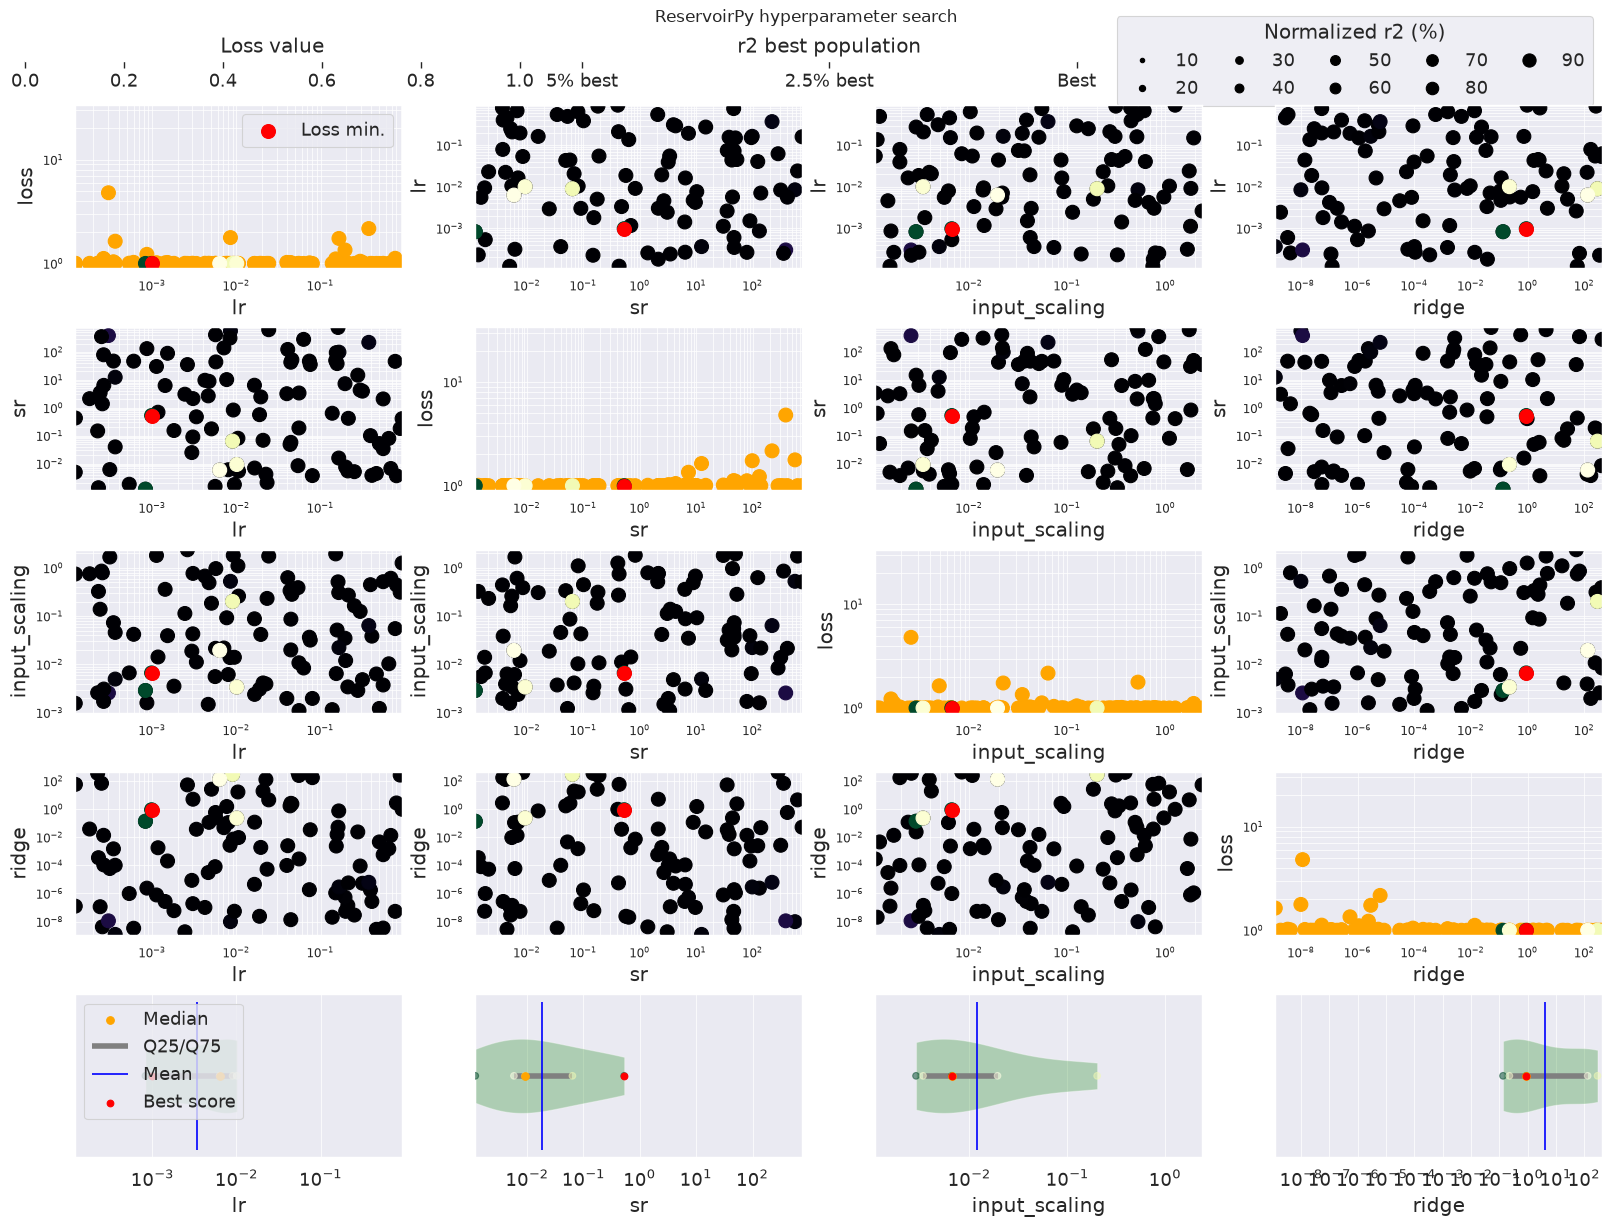

In [26]:
with tempfile.TemporaryDirectory(prefix="hyperopt-plot-") as plot_dir:
    flat_experiment_dir = build_flat_hyperopt_report_dir(experiment_dir, Path(plot_dir))
    fig = plot_hyperopt_report(
        flat_experiment_dir,
        ("lr", "sr", "input_scaling", "ridge"),
        metric="r2",
        loss_metric="loss",
        loss_behaviour="min",
    )

fig.set_size_inches(*HYPEROPT_PLOT_FIGSIZE, forward=True)
fig.set_dpi(HYPEROPT_PLOT_DPI)
fig.suptitle("ReservoirPy hyperparameter search", y=1.01)

report_path = experiment_dir / f"{HYPEROPT_REPORT_PREFIX}_{experiment_dir.name}.pdf"
fig.savefig(report_path, format="pdf", bbox_inches="tight")
print("Saved report to:", report_path)

fig

## 12. Checklist for adapting this notebook

Before running a real analysis:

1. Replace the demo `series_list` with your own data.
2. Confirm that each series has shape `(timesteps, features)`.
3. Choose whether `LAG = 1` is appropriate, or whether your prediction should be delayed.
4. Choose a `WARMUP` long enough to discard initial reservoir transients.
5. Increase `hp_max_evals`, `instances_per_trial`, and `N` for a real search.
6. If you add a parameter to `hp_space`, also add it to the objective function signature and use it inside the objective.
7. Watch memory use if you increase `RESERVOIR_WORKERS` or use many parallel hyperopt trials.